In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('spam.csv', encoding='latin-1')

In [3]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


Since the last three columns have very large number of null values therefore we drop them

In [5]:
lis=['Unnamed: 2','Unnamed: 3','Unnamed: 4']
df.drop(columns=lis,inplace=True)

In [6]:
# renaming column name:
df.rename(columns={'v1':'Spam/ham','v2':'Text'},inplace=True)
df.head()

,Spam/ham,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
df['Spam/ham'] = df['Spam/ham'].astype(str).apply(lambda x: 0 if x == 'ham' else 1)
df.head()

,Spam/ham,Text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


checking missing values:

In [8]:
df.isnull().sum()

Spam/ham    0
Text        0
dtype: int64

no missing values

check for duplicates:

In [9]:
df=df.drop_duplicates(keep='first')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5169 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Spam/ham  5169 non-null   int64 
 1   Text      5169 non-null   object
dtypes: int64(1), object(1)
memory usage: 121.1+ KB


## EDA:

In [10]:
df['Spam/ham'].value_counts()

Spam/ham
0    4516
1     653
Name: count, dtype: int64

### Visual represntation:

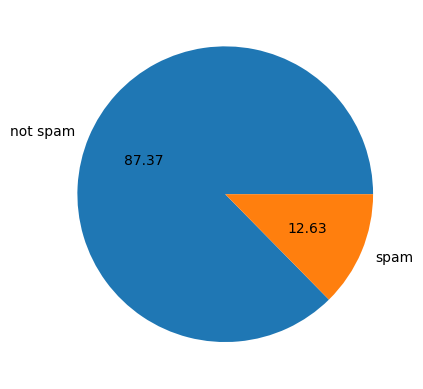

In [11]:
plt.pie(df['Spam/ham'].value_counts(),labels=['not spam','spam'],autopct="%0.2f")
plt.show()

from this we understand that the data is imbalanced.

second analysis that we could do is to find the number of letters and alphabets and sentences in the text column and a mke  new columns. for that we need to import a new library called as "nltk", this library helps us break the given text in a token form which is used in NLPs can be used for words or for sentences.


In [12]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\KIIT0001\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [13]:
# for a column to store the number of charaters :
df['num_characters']=df['Text'].apply(len)
df.head()

,Spam/ham,Text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [14]:
# for getting the number of words:
df['num_words']=df['Text'].apply(lambda x: len(nltk.word_tokenize(x)))
df.head()

,Spam/ham,Text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [15]:
# for getting the number of sentences:
df['nun_sentences']=df['Text'].apply(lambda x: len(nltk.sent_tokenize(x)))
df.head()

,Spam/ham,Text,num_characters,num_words,nun_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [16]:
# for not spam messages:
df[df['Spam/ham']==0][['num_characters','num_words','nun_sentences']].describe()

,num_characters,num_words,nun_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459699,17.123782,1.820195
std,56.358868,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [17]:
# for spam messages:
df[df['Spam/ham']==1][['num_characters','num_words','nun_sentences']].describe()

,num_characters,num_words,nun_sentences
count,653.000000,653.000000,653.000000
mean,137.889740,27.664625,2.969372
std,30.137213,7.008710,1.489939
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


### visual representaion

In [18]:
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Count'>

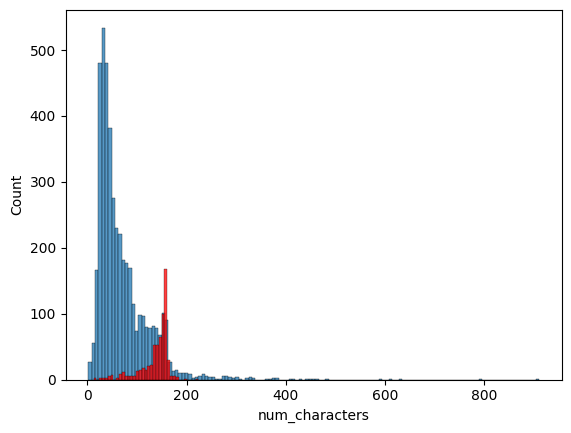

In [19]:
sns.histplot(df[df['Spam/ham']==0]['num_characters'])
sns.histplot(df[df['Spam/ham']==1]['num_characters'],color='red')

<Axes: xlabel='num_words', ylabel='Count'>

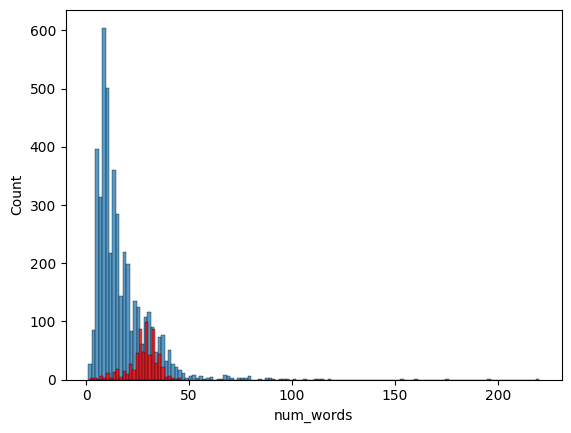

In [20]:
sns.histplot(df[df['Spam/ham']==0]['num_words'])
sns.histplot(df[df['Spam/ham']==1]['num_words'],color='red')

from these graphs we can say that the number of words that are used in a sapm message is more than that for a non spam message. similarly the character count for a non spam message is less than the spam message.

## Data pre-processing:

here we need to complete the following tasks:

**Lower case**

**Tokenization**

**Removing of special characters**

**Removing of punction marks and stop words**

**Stemming**

In [21]:
# for removing stop words:

from nltk.corpus import stopwords
stopwords.words('english')

['i',
 'me',
 'my',
 'myself',
 'we',
 'our',
 'ours',
 'ourselves',
 'you',
 "you're",
 "you've",
 "you'll",
 "you'd",
 'your',
 'yours',
 'yourself',
 'yourselves',
 'he',
 'him',
 'his',
 'himself',
 'she',
 "she's",
 'her',
 'hers',
 'herself',
 'it',
 "it's",
 'its',
 'itself',
 'they',
 'them',
 'their',
 'theirs',
 'themselves',
 'what',
 'which',
 'who',
 'whom',
 'this',
 'that',
 "that'll",
 'these',
 'those',
 'am',
 'is',
 'are',
 'was',
 'were',
 'be',
 'been',
 'being',
 'have',
 'has',
 'had',
 'having',
 'do',
 'does',
 'did',
 'doing',
 'a',
 'an',
 'the',
 'and',
 'but',
 'if',
 'or',
 'because',
 'as',
 'until',
 'while',
 'of',
 'at',
 'by',
 'for',
 'with',
 'about',
 'against',
 'between',
 'into',
 'through',
 'during',
 'before',
 'after',
 'above',
 'below',
 'to',
 'from',
 'up',
 'down',
 'in',
 'out',
 'on',
 'off',
 'over',
 'under',
 'again',
 'further',
 'then',
 'once',
 'here',
 'there',
 'when',
 'where',
 'why',
 'how',
 'all',
 'any',
 'both',
 'each

In [22]:
# for punctuation marks:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [23]:
# for steming:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()     


used for bring all the words into it's shortest form

In [24]:
# transforming the text:

def Text_transform(text):
    text=text.lower()                       # transforming to lower case.
    text=nltk.word_tokenize(text)           # tokenizing words.
    y=[]                    
    for i in text:      
        if i.isalnum(): 
            y.append(i)                     # removing special characters.

    text=y[:]
    y.clear()
    for i in text:
        if i not in string.punctuation and i not in stopwords.words('english'):
            y.append(i)    
    
    text = y[:]
    y.clear()
    for i in text:
        y.append(ps.stem(i))

    return " ".join(y)

In [25]:
df['Transformde_text']=df['Text'].apply(Text_transform)

In [26]:
df.head()

,Spam/ham,Text,num_characters,num_words,nun_sentences,Transformde_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


## Using wordcloud:

this library here is used to make all the important words highlighted and increased font size. so we can use this to find out which type of words are used in the spam messages.

In [27]:
from wordcloud import WordCloud
wc=WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [28]:
# for spam message:
spam_wc=wc.generate(df[df['Spam/ham']==1]['Transformde_text'].str.cat(sep=" "))

## visual representaion:

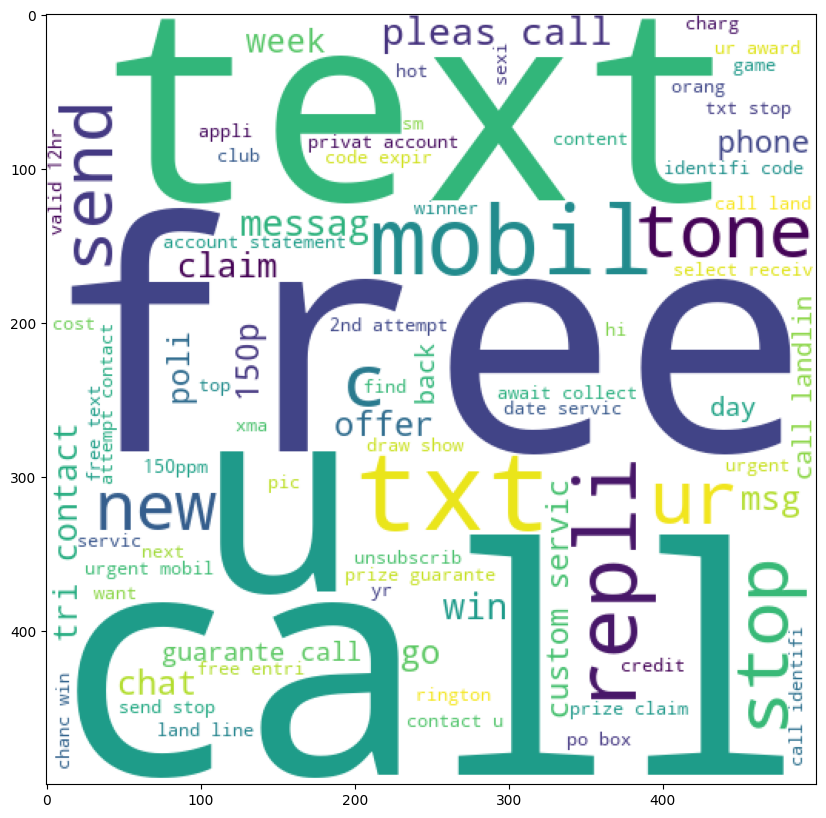

In [29]:
plt.figure(figsize=(10,10))
plt.imshow(spam_wc)

In [30]:
# for not spam messages:
not_spam_wc=wc.generate(df[df['Spam/ham']==0]['Transformde_text'].str.cat(sep=" "))

## visual representaion:

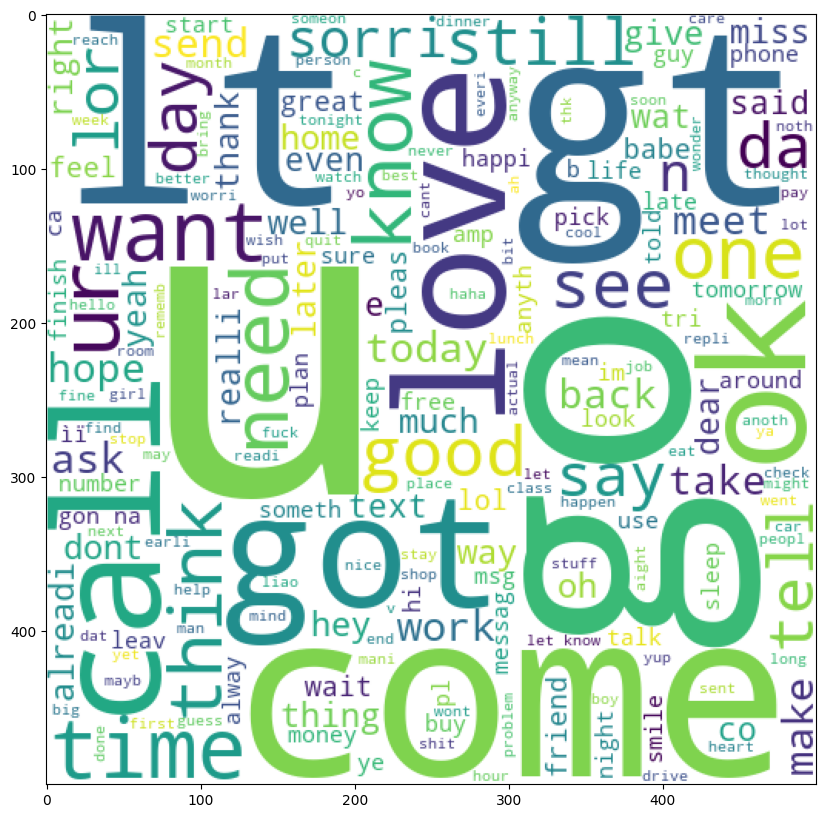

In [31]:
plt.figure(figsize=(10,10))
plt.imshow(not_spam_wc)

##  MOST FREQUENTLY USED WORDS IN A SPAM:

after the visual representaion we can see the  most used words now in order to identify them by the model we need to make a count list to check whic word is used most frequently.

In [32]:
top_words=[]
for sentence in df[df['Spam/ham']==1]['Transformde_text'].to_list():
    for word in sentence.split():
        top_words.append(word)
len (top_words)

9939

we can see that there are total of 9930 words in the spam messages.

In [33]:
from collections import Counter
spamTopWords=pd.DataFrame(Counter(top_words).most_common(30),columns=['words','count'])

## Visual representaion

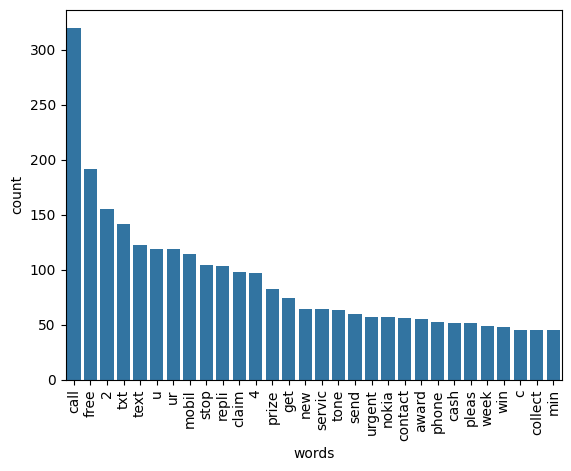

In [34]:
sns.barplot(x='words',y='count',data=spamTopWords)
plt.xticks(rotation="vertical")
plt.show()

##  MOST FREQUENTLY USED WORDS IN NOT A SPAM MESSAGE:

In [35]:
top_words=[]
for sentence in df[df['Spam/ham']==0]['Transformde_text'].to_list():
    for word in sentence.split():
        top_words.append(word)
len (top_words)

35404

we can see that there are total of 35404 words in not a spam messages.

In [36]:
from collections import Counter
notSpamTopWords=pd.DataFrame(Counter(top_words).most_common(30),columns=['words','count'])

## Visual representaion

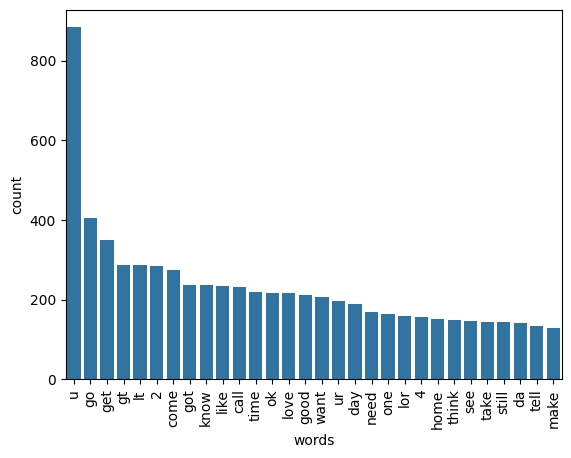

In [37]:
sns.barplot(x='words',y='count',data=notSpamTopWords)
plt.xticks(rotation="vertical")
plt.show()

## MODEL BUILDING (using naive bayes algo):

In [54]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv=CountVectorizer()
tfid=TfidfVectorizer()


In [55]:
x=tfid.fit_transform(df['Transformde_text']).toarray()

In [56]:
x.shape

(5169, 6708)

In [57]:
y=df['Spam/ham'].values

In [58]:
from sklearn.model_selection import train_test_split

In [59]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [60]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [61]:
gnb=GaussianNB()
mnb=MultinomialNB()
bnb=BernoulliNB()

### using the Gaussian NB method:

In [62]:
gnb.fit(x_train,y_train)
y_pred1 = gnb.predict(x_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))


0.8762088974854932
[[793 103]
 [ 25 113]]
0.5231481481481481


### using the Multinomial NB method:

In [63]:
mnb.fit(x_train,y_train)
y_pred2 = mnb.predict(x_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))


0.9593810444874274
[[896   0]
 [ 42  96]]
1.0


### using the Bernoulli NB method:

In [64]:
bnb.fit(x_train,y_train)
y_pred3 = bnb.predict(x_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))


0.9700193423597679
[[893   3]
 [ 28 110]]
0.9734513274336283


### Analysis of all the above algo:

we can see that out of all the above algo we get the best score from the multinoial NB methhod and using it with the Tfid vectorised method, the precession score is the highest and thus is the optimal algo for our model.

## Creating a pipeline:

In [66]:
import pickle
pickle.dump(tfid,open('vectorised.pkl','wb'))  # exporting the vectoriser.
pickle.dump(mnb,open('model.pkl','wb'))        # exporting the model.

In [67]:
pickle.dump(Text_transform,open('Text_transform.pkl','wb')) # exporting the preprocessing method